# Dimensionality Reduction using PCA (Principal Component Analysis) on Iris Dataset 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [7]:
# Load dataset (Iris dataset: 150 flowers, 3 species, 4 features)
iris = load_iris()
X = iris.data   # Features: sepal length, sepal width, petal length, petal width
y = iris.target # Target: species of iris (setosa, versicolor, virginica)

target_names = iris.target_names 
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [8]:
y[:5]

array([0, 0, 0, 0, 0])

In [9]:
X_scaled = StandardScaler().fit_transform(X)

# Standardize features (mean=0, variance=1)
# Why? PCA is affected by scale.
# Features with larger values dominate if not standardized.

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [10]:
pca = PCA(n_components=4)

X_pca = pca.fit_transform(X_scaled)  # transform original features into principal components

# Apply PCA (ask for 4 components because original data has 4 features)

# PCA will re-express data in terms of new uncorrelated components
X_pca[:5]

array([[-2.26470281,  0.4800266 ,  0.12770602, -0.0241682 ],
       [-2.08096115, -0.67413356,  0.23460885, -0.10300677],
       [-2.36422905, -0.34190802, -0.04420148, -0.02837705],
       [-2.29938422, -0.59739451, -0.09129011,  0.06595556],
       [-2.38984217,  0.64683538, -0.0157382 ,  0.03592281]])

In [11]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


In [12]:
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))

Cumulative variance explained: [0.72962445 0.95813207 0.99482129 1.        ]


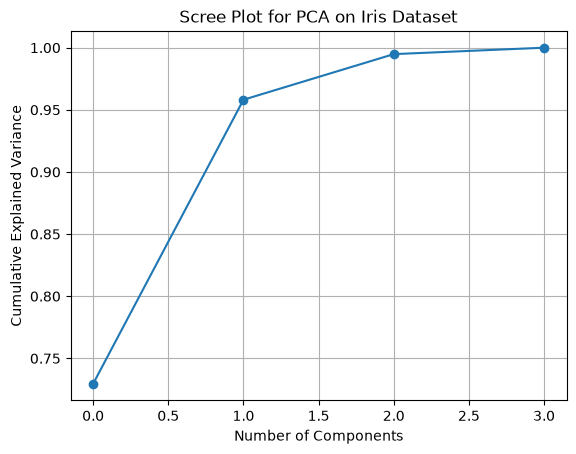

In [14]:
# Why? To visualize the "elbow point" where adding more components gives little extra benefit
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot for PCA on Iris Dataset")
plt.grid(True)
plt.show()

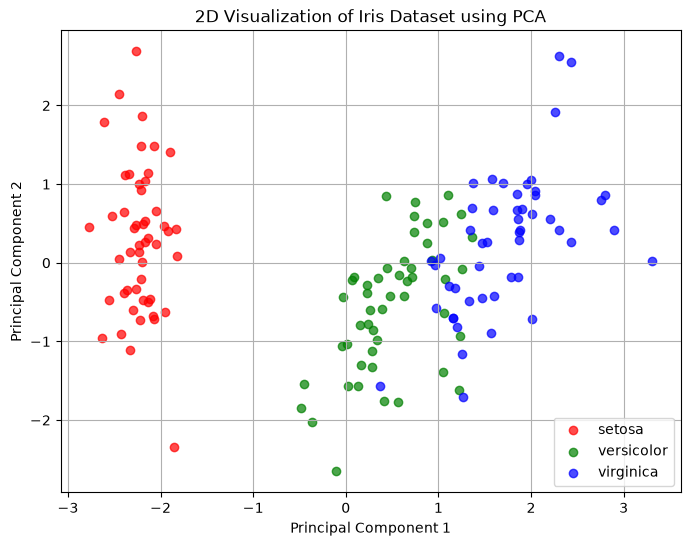

In [15]:
# Step 4: Scatter plot of 2D PCA-transformed data
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']

for i, target in enumerate(np.unique(y)):
    plt.scatter(X_pca[y==target, 0], X_pca[y==target, 1], 
                color=colors[i], label=target_names[i], alpha=0.7)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("2D Visualization of Iris Dataset using PCA")

plt.legend()
plt.grid(True)
plt.show()